<a href="https://colab.research.google.com/github/bhupeshupadhayay6-cpu/EX1/blob/main/linearregression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (20640, 8)
Target shape: (20640,)

--- Normal Equation ---
MSE: 0.5558915986952424
R2 Score: 0.5757877060324523

--- Gradient Descent ---
MSE: 0.554579506530855
R2 Score: 0.5767889905063641

--- Scikit-learn Linear Regression ---
MSE: 0.5558915986952442
R2 Score: 0.575787706032451

--- Ridge Regression ---
MSE: 0.5558548589435974
R2 Score: 0.575815742891368

--- Lasso Regression ---
MSE: 0.5482548967938964
R2 Score: 0.5816154300698727

             MODEL COMPARISON
Normal Equation       MSE = 0.5559, R2 = 0.5758
Gradient Descent      MSE = 0.5546, R2 = 0.5768
Linear Regression     MSE = 0.5559, R2 = 0.5758
Ridge Regression      MSE = 0.5559, R2 = 0.5758
Lasso Regression      MSE = 0.5483, R2 = 0.5816


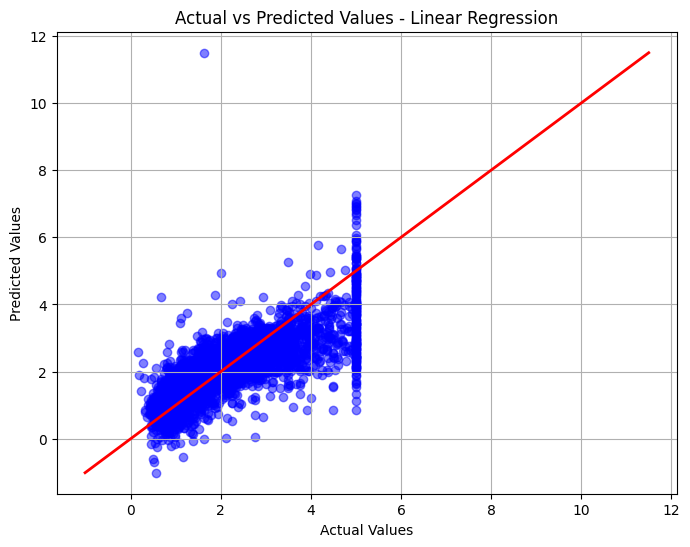

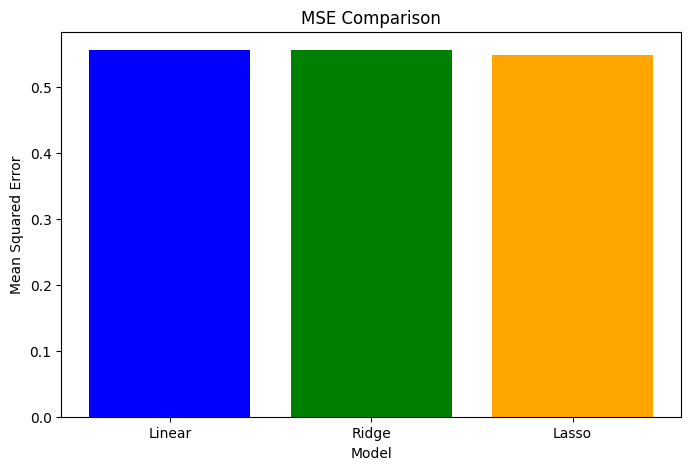

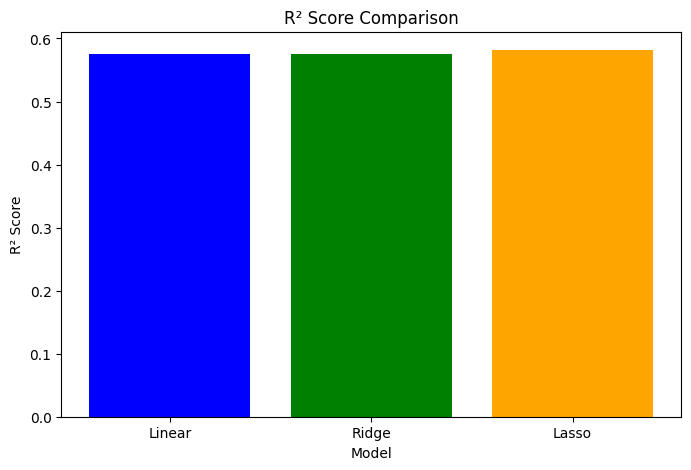

In [ ]:
# Lab Experiment 1: Linear Regression and Regularization

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score


# ---------------------------------------------------------
# 1. Load California Housing Dataset
# ---------------------------------------------------------

housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)


# ---------------------------------------------------------
# 2. Train-Test Split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Standardization is useful for Gradient Descent,
# Ridge and Lasso.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Add bias/intercept column
X_train_bias = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_bias = np.c_[np.ones(X_test_scaled.shape[0]), X_test_scaled]


# ---------------------------------------------------------
# 3. Linear Regression using Normal Equation
# ---------------------------------------------------------

def normal_equation(X, y):
    """
    Calculates regression coefficients using:

        theta = (X^T X)^(-1) X^T y
    """
    theta = np.linalg.pinv(X.T @ X) @ X.T @ y
    return theta


theta_normal = normal_equation(X_train_bias, y_train)

y_pred_normal = X_test_bias @ theta_normal


mse_normal = mean_squared_error(y_test, y_pred_normal)
r2_normal = r2_score(y_test, y_pred_normal)

print("\n--- Normal Equation ---")
print("MSE:", mse_normal)
print("R2 Score:", r2_normal)


# ---------------------------------------------------------
# 4. Linear Regression using Gradient Descent
# ---------------------------------------------------------

def gradient_descent(X, y, learning_rate=0.01, iterations=1000):

    m, n = X.shape

    theta = np.zeros(n)

    for i in range(iterations):

        predictions = X @ theta

        errors = predictions - y

        gradients = (2 / m) * X.T @ errors

        theta = theta - learning_rate * gradients

    return theta


theta_gd = gradient_descent(
    X_train_bias,
    y_train,
    learning_rate=0.01,
    iterations=1000
)

y_pred_gd = X_test_bias @ theta_gd


mse_gd = mean_squared_error(y_test, y_pred_gd)
r2_gd = r2_score(y_test, y_pred_gd)

print("\n--- Gradient Descent ---")
print("MSE:", mse_gd)
print("R2 Score:", r2_gd)


# ---------------------------------------------------------
# 5. Linear Regression using Scikit-learn
# ---------------------------------------------------------

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)


mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("\n--- Scikit-learn Linear Regression ---")
print("MSE:", mse_linear)
print("R2 Score:", r2_linear)


# ---------------------------------------------------------
# 6. Ridge Regression
# ---------------------------------------------------------

ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)


mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\n--- Ridge Regression ---")
print("MSE:", mse_ridge)
print("R2 Score:", r2_ridge)


# ---------------------------------------------------------
# 7. Lasso Regression
# ---------------------------------------------------------

lasso_model = Lasso(alpha=0.01)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)


mse_lasso = mean_squared_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n--- Lasso Regression ---")
print("MSE:", mse_lasso)
print("R2 Score:", r2_lasso)


# ---------------------------------------------------------
# 8. Compare Results
# ---------------------------------------------------------

print("\n==============================================")
print("             MODEL COMPARISON")
print("==============================================")

print(f"Normal Equation       MSE = {mse_normal:.4f}, "
      f"R2 = {r2_normal:.4f}")

print(f"Gradient Descent      MSE = {mse_gd:.4f}, "
      f"R2 = {r2_gd:.4f}")

print(f"Linear Regression     MSE = {mse_linear:.4f}, "
      f"R2 = {r2_linear:.4f}")

print(f"Ridge Regression      MSE = {mse_ridge:.4f}, "
      f"R2 = {r2_ridge:.4f}")

print(f"Lasso Regression      MSE = {mse_lasso:.4f}, "
      f"R2 = {r2_lasso:.4f}")


# ---------------------------------------------------------
# 9. Plot Actual vs Predicted Values
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_linear,
    alpha=0.5,
    color="blue"
)

# Ideal prediction line
minimum = min(y_test.min(), y_pred_linear.min())
maximum = max(y_test.max(), y_pred_linear.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values - Linear Regression")

plt.grid(True)
plt.show()


# ---------------------------------------------------------
# 10. Compare Regularization Models
# ---------------------------------------------------------

models = ["Linear", "Ridge", "Lasso"]

mse_values = [
    mse_linear,
    mse_ridge,
    mse_lasso
]

r2_values = [
    r2_linear,
    r2_ridge,
    r2_lasso
]


# MSE Plot
plt.figure(figsize=(8, 5))

plt.bar(models, mse_values, color=["blue", "green", "orange"])

plt.xlabel("Model")
plt.ylabel("Mean Squared Error")
plt.title("MSE Comparison")

plt.show()


# R2 Plot
plt.figure(figsize=(8, 5))

plt.bar(models, r2_values, color=["blue", "green", "orange"])

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison")

plt.show()
